<a href="https://colab.research.google.com/github/Jake0925/DeepLearning/blob/master/Logistic_%EA%B5%AC%ED%98%841.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/deeplearningzerotoall/TensorFlow/blob/master/tf_2.x/lab-05-1-logistic_regression-eager.ipynb


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf

tf.random.set_seed(777)  # for reproducibility
print(tf.__version__)

2.18.0


데이터

In [ ]:
x_train = [[1., 2.],
          [2., 3.],
          [3., 1.],
          [4., 3.],
          [5., 3.],
          [6., 2.]]
y_train = [[0.],
          [0.],
          [0.],
          [1.],
          [1.],
          [1.]]


# xy = np.loadtxt('data-03-diabetes.csv', delimiter=',', dtype=np.float32)
# x_train = xy[:, 0:-1]
# y_train = xy[:, [-1]]


In [ ]:
x_test = [[5.,2.]] # 테스트로 사용할 좌표
y_test = [[1.]]    # 테스트 좌표에 대한 실제값

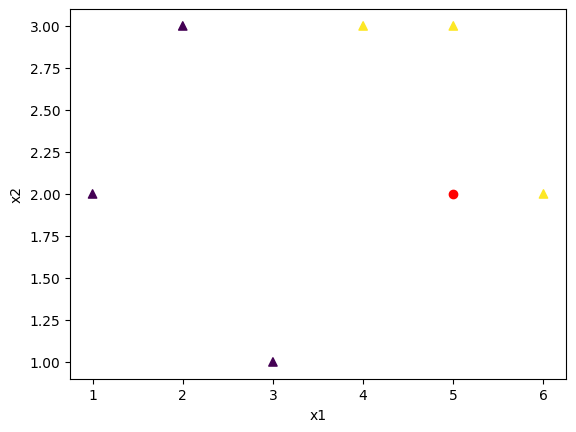

In [ ]:
# 그래프 그리기
x1 = [x[0] for x in x_train]
x2 = [x[1] for x in x_train]

colors = [int(y[0] % 3) for y in y_train]
plt.scatter(x1,x2, c=colors , marker='^')
plt.scatter(x_test[0][0],x_test[0][1], c="red")

plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Tensorflow data API를 통해 학습시킬 값들을 담는다 (Batch Size는 한번에 학습시킬 Size로 정한다)

features,labels는 실재 학습에 쓰일 Data (연산을 위해 Type를 맞춰준다)

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(len(x_train))# 현재 batch size는 모든데이터의 크기만큼으로 설정함
dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

In [ ]:
W = tf.Variable(tf.zeros([2,1]), name='weight') # 입력값이 2개이므로 가중치(w)도 2개가 필요하다
b = tf.Variable(tf.zeros([1]), name='bias')

# 시그모이드 함수

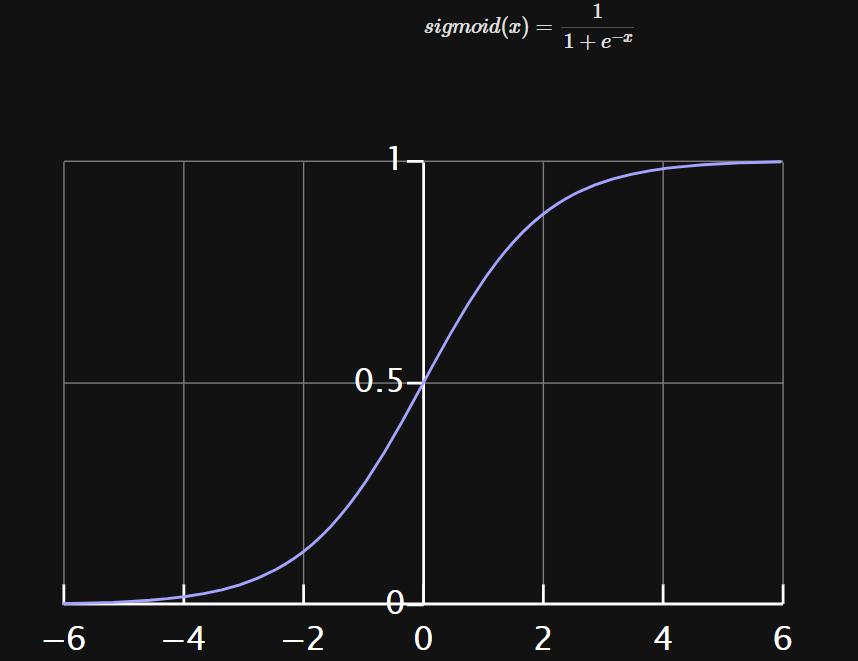

In [ ]:
# 시그모이드 함수
def logistic_regression(features):
    hypothesis  = tf.divide(1., 1. + tf.exp(tf.matmul(features, W) + b))
    return hypothesis

# 로지스틱 비용함수

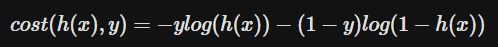

In [ ]:
def loss_fn(hypothesis, features, labels):
    cost = -tf.reduce_mean(labels * tf.math.log(logistic_regression(features)) + (1 - labels) * tf.math.log(1 - hypothesis)) # 시그모이드함수를 통한 예측값과 실제값의 차이를 log함수를통해 비용계산
    return cost

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

# 정확도

Sigmoid 함수를 통해 예측값이 0.5보다 크면 1을 반환하고 0.5보다 작으면 0으로 반환

예측값과 실제값 차의 평균

In [ ]:
def accuracy_fn(hypothesis, labels):
    predicted = tf.cast(hypothesis > 0.5, dtype=tf.float32) # 예측값, tf.cast - 소수점을 정수형으로 변환, bool의경우 참은1 거짓은 0을 반환
    accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted, labels), dtype=tf.int32)) # 실제값과 예측값 비교값의 평균, tf.equal 두원소가 갖다면 True, 다르면 False 반환
    return accuracy

# 미분값 계산

In [ ]:
def grad(features, labels):
    with tf.GradientTape() as tape:
        loss_value = loss_fn(logistic_regression(features),features,labels) # 비용함수
    return tape.gradient(loss_value, [W,b]) # 비용함수값을 이용하여 w와 b의 미분값 계산

# 학습

In [ ]:
EPOCHS = 1001

for step in range(EPOCHS):
    for features, labels  in iter(dataset):  # features, labels는 x_train, y_train 데이터를 의미한다
        grads = grad(features, labels) # 미분계산
        optimizer.apply_gradients(grads_and_vars=zip(grads,[W,b])) # 미분값을 적용하여 w와 b값을 구한다
        if step % 100 == 0:
            print("Iter: {}, Loss: {:.4f}".format(step, loss_fn(logistic_regression(features),features,labels)))

test_acc = accuracy_fn(logistic_regression(x_test),y_test) # 예측값과 실제값을 비교하여 정확도 확인
print("Testset Accuracy: {:.4f}".format(test_acc))

Iter: 0, Loss: 0.6874
Iter: 100, Loss: 0.5776
Iter: 200, Loss: 0.5349
Iter: 300, Loss: 0.5054
Iter: 400, Loss: 0.4838
Iter: 500, Loss: 0.4671
Iter: 600, Loss: 0.4535
Iter: 700, Loss: 0.4420
Iter: 800, Loss: 0.4319
Iter: 900, Loss: 0.4228
Iter: 1000, Loss: 0.4144
Testset Accuracy: 1.0000
